<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
C:\Users\snaha\AppData\Local\Temp\ipykernel_13024\2358826249.py:10: SyntaxWarning: invalid escape sequence '\$'
  df["Trade Value (US$)"] = df["Trade Value (US$)"].replace('[\$,]', '', regex=True).astype(float)
C:\Users\snaha\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\snaha\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\snaha\AppData\Local\Programs\Python\Python313\Lib\


Imports Accuracy:
MAE: 70663385.29
RMSE: 79375737.08
2023: Pred 1295058786.35, Actual 1329567039.0, Error 2.60%
2024: Pred 1293269077.07, Actual 1400087595.0, Error 7.63%

Exports Accuracy (ARIMAX):
MAE: 73209916.56
RMSE: 88569896.68
2023: Pred 807086820.05, Actual 783726023.0, Error 2.98%
2024: Pred 877057932.07, Actual 753998896.0, Error 16.32%


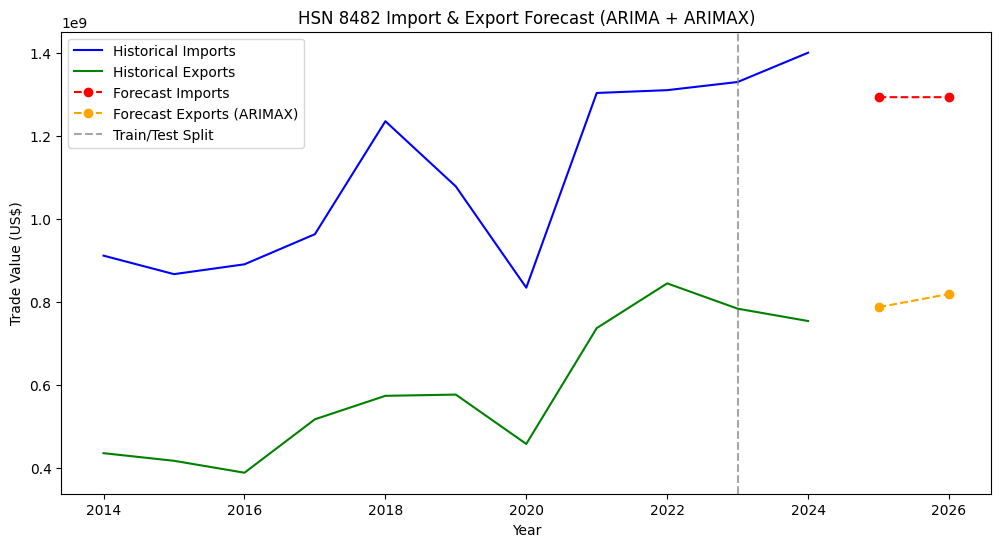


Forecasts (2025 & 2026):

Year 2025: Imports → 1,293,053,838.49 US$, Exports → 787,331,237.00 US$
Year 2026: Imports → 1,293,027,952.92 US$, Exports → 819,132,972.86 US$


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv(r"HSN8482_2014_2024.csv")
df = df[["Period", "Trade Flow", "Trade Value (US$)"]]
df["Trade Value (US$)"] = df["Trade Value (US$)"].replace('[\$,]', '', regex=True).astype(float)
df["Trade Flow"] = df["Trade Flow"].map({"M": "Import", "X": "Export"})

pivot = df.pivot_table(index="Period", columns="Trade Flow", values="Trade Value (US$)", aggfunc="sum").reset_index()
imports = pivot.set_index("Period")["Import"]
exports = pivot.set_index("Period")["Export"]

train_imp = imports[:-2]
test_imp = imports[-2:]
train_exp = exports[:-2]
test_exp = exports[-2:]


model_import = ARIMA(train_imp, order=(1,1,1))
fit_import = model_import.fit()
pred_imp = fit_import.forecast(steps=2)
future_imp = fit_import.forecast(steps=4)[-2:]


model_export = SARIMAX(train_exp, order=(1,1,1), exog=train_imp)
fit_export = model_export.fit(disp=False)
pred_exp = fit_export.forecast(steps=2, exog=test_imp)
future_exp = fit_export.forecast(steps=2, exog=future_imp)


mae_imp = mean_absolute_error(test_imp, pred_imp)
rmse_imp = np.sqrt(mean_squared_error(test_imp, pred_imp))
mae_exp = mean_absolute_error(test_exp, pred_exp)
rmse_exp = np.sqrt(mean_squared_error(test_exp, pred_exp))

print("\nImports Accuracy:")
print("MAE:", round(mae_imp, 2))
print("RMSE:", round(rmse_imp, 2))
for year, pred, actual in zip(test_imp.index, pred_imp, test_imp):
    pct_error = abs(pred - actual) / actual * 100
    print(f"{year}: Pred {pred:.2f}, Actual {actual}, Error {pct_error:.2f}%")

print("\nExports Accuracy (ARIMAX):")
print("MAE:", round(mae_exp, 2))
print("RMSE:", round(rmse_exp, 2))
for year, pred, actual in zip(test_exp.index, pred_exp, test_exp):
    pct_error = abs(pred - actual) / actual * 100
    print(f"{year}: Pred {pred:.2f}, Actual {actual}, Error {pct_error:.2f}%")

last_year = imports.index.max()
forecast_years = [last_year+1, last_year+2]

plt.figure(figsize=(12,6))
plt.plot(imports.index, imports, label="Historical Imports", color="blue")
plt.plot(exports.index, exports, label="Historical Exports", color="green")
plt.plot(forecast_years, future_imp, "--", color="red", marker="o", label="Forecast Imports")
plt.plot(forecast_years, future_exp, "--", color="orange", marker="o", label="Forecast Exports (ARIMAX)")
plt.axvline(test_imp.index[0], color="gray", linestyle="--", alpha=0.7, label="Train/Test Split")
plt.xlabel("Year")
plt.ylabel("Trade Value (US$)")
plt.title("HSN 8482 Import & Export Forecast (ARIMA + ARIMAX)")
plt.legend()
plt.show()

print("\nForecasts (2025 & 2026):\n")
for year, imp, exp in zip(forecast_years, future_imp, future_exp):
    print(f"Year {year}: Imports → {imp:,.2f} US$, Exports → {exp:,.2f} US$")